This project is about LIME as an Interpretable Machine Learning approach

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("winequality-red.csv")

In [3]:
# See the number of rows and columns
print("Rows, columns: " + str(df.shape))

Rows, columns: (1599, 12)


In [4]:
# See the first five rows of the dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
X_feature_names = [i for i in df.columns if df[i].dtype in [float]]

In [6]:
print(X_feature_names)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [7]:
Y_feature_names = [i for i in df.columns if df[i].dtype in [np.int64]]

In [8]:
print(Y_feature_names)

['quality']


Task 1: Check for any missing values in the dataset

In [9]:
# Your code for task 1

# Check for missing values in the dataset
missing_values = df.isnull().sum()

# Display the count of missing values for each column
print("Missing Values are")
print(missing_values)

Missing Values are
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Task 2:** Create a binary classification version of the target variable "quality" in that all wines with scores greater or equal with 7 are classified as 1, i.e., good quality, otherwise they should be classified as 0, i.e., bad quality. Subsequently, separate feature variables from target variable by creating two data frames and check contents for validation purposes..

In [10]:
# Your code for task 2
# Create a binary classification version of the target variable
df['binary_quality'] = np.where(df['quality'] >= 7, 1, 0)


In [11]:
# Check your task 2 solution
# Separate feature variables (X) and target variable (Y)
X = df.drop(['quality', 'binary_quality'], axis=1)  # Drop 'quality' and 'binary_quality' columns
Y = df['binary_quality']

# Display the contents for validation
print("Feature Variables (X):")
print(X.head())

print("\nTarget Variable (Y):")
print(Y.head())

Feature Variables (X):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8 

In [12]:
# Normalize feature variables
from sklearn.preprocessing import StandardScaler

In [13]:
# Splitting the data
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=0)

In [14]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

**Task 3:** Following the data preparation stages above, train the following three prediction models (classifiers): Decision Tree, Random Forest and Ada Boost. Subsequently, create classification reports including precision, recall, f1-score for each classifier and compare / discuss the results.

Tip: The imported package above might be of help!

In [15]:
# Your code for task 3

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, Y_train)

# Make predictions
dt_predictions = dt_classifier.predict(X_test)

# Generate classification report
dt_report = classification_report(Y_test, dt_predictions)

# Print classification report
print("Decision Tree Classifier Report:")
print(dt_report)

Decision Tree Classifier Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       273
           1       0.57      0.51      0.54        47

    accuracy                           0.87       320
   macro avg       0.74      0.72      0.73       320
weighted avg       0.87      0.87      0.87       320



Your discussion to task 3.

The Decision Tree classifier achieved an overall accuracy of 87%, with higher precision and recall for class 0 (bad quality) compared to class 1 (good quality). The model's performance, as indicated by macro and weighted averages, demonstrates a relatively better ability to identify instances of bad quality wine. Potential improvements could involve model tuning or exploring alternative classifiers for better discrimination of instances in the positive class (good quality).

**Task 4:** Get a feature importance diagram for the Random Forest classifier.

The documentation here might help: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

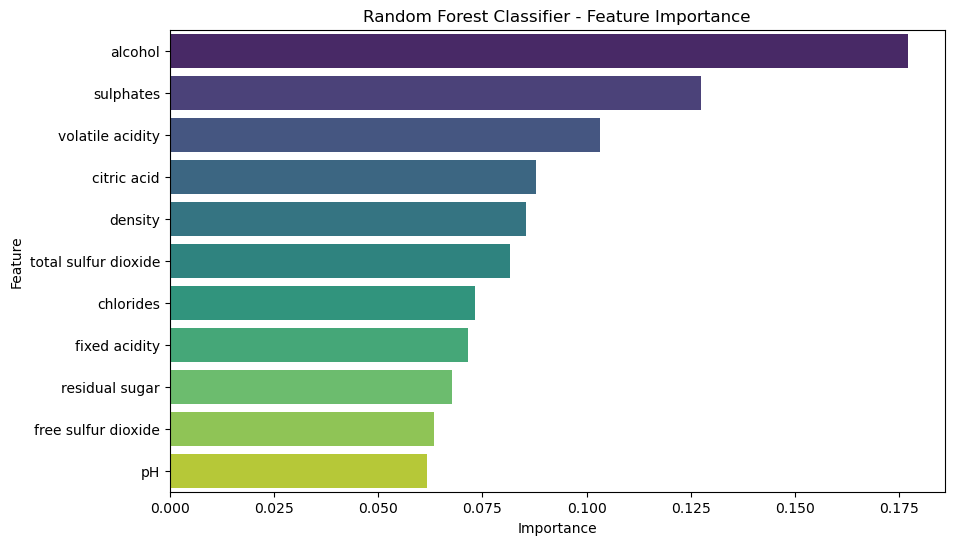

In [16]:
# Your code for task 4

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=0)
rf_classifier.fit(X_train, Y_train)

# Get feature importances from the trained model
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance diagram
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Classifier - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [17]:
# !pip install lime

In [18]:
import lime
import lime.lime_tabular as lt

In [19]:
all_feature_names = sum([X_feature_names, Y_feature_names], [])

In [20]:
print(all_feature_names)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


#### Task 5: Locate entries in the test dataset for which wines with good quality have been predicted regardless the trained classifier being used. Subsequently, uncomment as appropriate and run the explainer below.

In [21]:

# Make predictions on the test set
test_predictions = rf_classifier.predict(X_test)

# Identify entries where wines with good quality have been predicted
good_quality_predictions = X_test.loc[test_predictions == 1]
instance_to_explain = good_quality_predictions.iloc[0]

In [22]:
explainer = lime.lime_tabular.LimeTabularExplainer(np.array(X_train),
                    feature_names=X_feature_names,
                    class_names=['goodquality'],
                    categorical_features=['goodquality'], 
                    # There is no categorical features in this example, otherwise specify them.
                    verbose=True, mode='regression')

#### Task 6: Fill in the input parameters for the explainer below to explain why the model(s) have predicted (classified) the wine as of good quality

In [23]:
exp = explainer.explain_instance(instance_to_explain.values,
    predict_fn=rf_classifier.predict_proba,
    num_features=len(all_feature_names))
#exp = explainer.explain_instance(instance_to_explain.values[0], predict_fn=rf_classifier.predict_proba, num_features=len(X_feature_names))


Intercept 0.907844634818201
Prediction_local [0.63502543]
Right: 0.21


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Well done, now:

**Task 7:** Explain the results of the ....explainer above.


Your explanation

The intercept of approximately 0.91 suggests a baseline inclination for predicting good quality in the specified instance. The local prediction of around 0.63 indicates that, considering local features, the model assigns a higher probability of the wine being of good quality. The original models probability for the positive class (0.21) suggests the local explanation contributes positively, influencing the prediction to be higher for good quality in this context.